In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

2026-05-09 09:53:07.749312: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:
# Path to the dataset folder you extracted
data_dir = "/Users/mac/Downloads/Drowsiness_Project/Dataset_of_eyes" 

img_height = 64
img_width = 64
batch_size = 32

# Load Training Data
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  color_mode="grayscale",
  image_size=(img_height, img_width),
  batch_size=batch_size)

# Load Validation Data
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  color_mode="grayscale",
  image_size=(img_height, img_width),
  batch_size=batch_size)

print("Classes:", train_ds.class_names)
# Make a mental note of the order. Usually: index 0 is 'closed_eye', index 1 is 'open_eye'

Found 48000 files belonging to 2 classes.
Using 38400 files for training.
Found 48000 files belonging to 2 classes.
Using 9600 files for validation.
Classes: ['closed_eye', 'open_eye']


In [9]:
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 1)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
# Training might take 5-10 minutes depending on your computer's CPU/GPU
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=10
)

# Save the model so you don't have to retrain it every time you open Jupyter
model.save("local_drowsiness_model.h5")
print("Model trained and saved successfully!")

Epoch 1/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 204s 168ms/step - accuracy: 0.9240 - loss: 0.1936 - val_accuracy: 0.9703 - val_loss: 0.0809
Epoch 2/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 151s 126ms/step - accuracy: 0.9736 - loss: 0.0782 - val_accuracy: 0.9843 - val_loss: 0.0453
Epoch 3/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 159s 132ms/step - accuracy: 0.9818 - loss: 0.0570 - val_accuracy: 0.9829 - val_loss: 0.0493
Epoch 4/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 155s 129ms/step - accuracy: 0.9851 - loss: 0.0450 - val_accuracy: 0.9872 - val_loss: 0.0392
Epoch 5/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 166s 138ms/step - accuracy: 0.9875 - loss: 0.0389 - val_accuracy: 0.9894 - val_loss: 0.0317
Epoch 6/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 156s 130ms/step - accuracy: 0.9881 - loss: 0.0358 - val_accuracy: 0.9903 - val_loss: 0.0305
Epoch 7/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 156s 130ms/step - accuracy: 0.9892 - loss: 0.0321 - val_accuracy: 0.9906 - val_loss: 0.0311
Epoch 8/10
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 158s 132ms/step - ac

Model trained and saved successfully!


In [5]:
# Load the saved model and Haar Cascades
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')
model = tf.keras.models.load_model("local_drowsiness_model.h5")
# Start Webcam
cap = cv2.VideoCapture(0)
score = 0
DROWSY_THRESHOLD = 15

print("Opening webcam... Press 'q' in the video window to close it.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame")
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5)

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
        roi_gray = gray[y:y + h, x:x + w]
        eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=5)

        eye_status = "Open" # Default to open

        for (ex, ey, ew, eh) in eyes:
            eye_crop = roi_gray[ey:ey + eh, ex:ex + ew]
            eye_crop = cv2.resize(eye_crop, (64, 64))
            
            # Show the cropped eye in a new window
            cv2.imshow("What the CNN sees", eye_crop)

            # FIX: Removed the / 255.0 division because your model already has a Rescaling layer!
            # FIX: Removed the duplicated code lines you had here.

            # Expand dimensions to match (batch, height, width, channels) -> (1, 64, 64, 1)
            eye_input = np.expand_dims(eye_crop, axis=-1)
            eye_input = np.expand_dims(eye_input, axis=0)

            # Predict
            prediction = model(eye_input, training=False)

            # 0 = closed_eye, 1 = open_eye (based on alphabetical folder sorting)
            if prediction[0][0] < 0.5:
                eye_status = "Closed"
                break # If ANY eye is closed, treat as closed

        # Score Logic (Aligned properly inside the faces loop)
        if eye_status == "Closed":
            score += 1
        else:
            score -= 1

        if score < 0:
            score = 0

        # Display Info
        cv2.putText(frame, f"Score: {score}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

        if score > DROWSY_THRESHOLD:
            cv2.putText(frame, "DROWSY WARNING! WAKE UP!", (10, 80), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)

    # Show the main feed
    cv2.imshow('Driver Drowsiness Detection', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Clean up hardware resources safely
cap.release()
cv2.destroyAllWindows()

Opening webcam... Press 'q' in the video window to close it.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# Assuming classes for Driver Drowsiness
classes = ['Alert', 'Drowsy']

def plot_training_history(history):
    """Generates Accuracy and Loss graphs"""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Accuracy Graph
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Accuracy Graph')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Graph
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Loss Graph')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def plot_confusion_matrix(y_true, y_pred):
    """Generates a Confusion Matrix heatmap"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='magma', 
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

def plot_roc_curve(y_true, y_score):
    """Generates the ROC Curve and AUC scores"""
    # For binary classification
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

def plot_metrics_comparison(report_dict):
    """Plots Precision, Recall, and F1-score"""
    labels = [k for k in report_dict.keys() if k in classes]
    precision = [report_dict[k]['precision'] for k in labels]
    recall = [report_dict[k]['recall'] for k in labels]
    f1 = [report_dict[k]['f1-score'] for k in labels]

    x = np.arange(len(labels))
    width = 0.2

    plt.figure(figsize=(10, 6))
    plt.bar(x - width, precision, width, label='Precision')
    plt.bar(x, recall, width, label='Recall')
    plt.bar(x + width, f1, width, label='F1-Score')

    plt.xticks(x, labels)
    plt.title('Precision, Recall, F1-score Comparison')
    plt.ylabel('Score')
    plt.legend()
    plt.show()

# --- Example Usage ---
# After training your model:
# plot_training_history(history)
# y_pred = model.predict(X_test).argmax(axis=1)
# y_score = model.predict(X_test)[:, 1] # Probability for ROC
# plot_confusion_matrix(y_test, y_pred)
# plot_roc_curve(y_test, y_score)

In [14]:
def plot_class_distribution(data_counts):
    plt.figure(figsize=(8, 5))
    plt.bar(classes, data_counts, color=['#1f77b4', '#ff7f0e'])
    plt.title('Class Distribution')
    plt.xlabel('Classes')
    plt.ylabel('Number of Images')
    plt.show()

# Example: plot_class_distribution([1200, 1150])

In [15]:
def plot_lr_optimization(val_acc_history):
    plt.figure(figsize=(8, 6))
    plt.plot(val_acc_history, label='LR=0.0001')
    plt.title('Learning Rate Optimization')
    plt.xlabel('Epochs')
    plt.ylabel('Validation Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

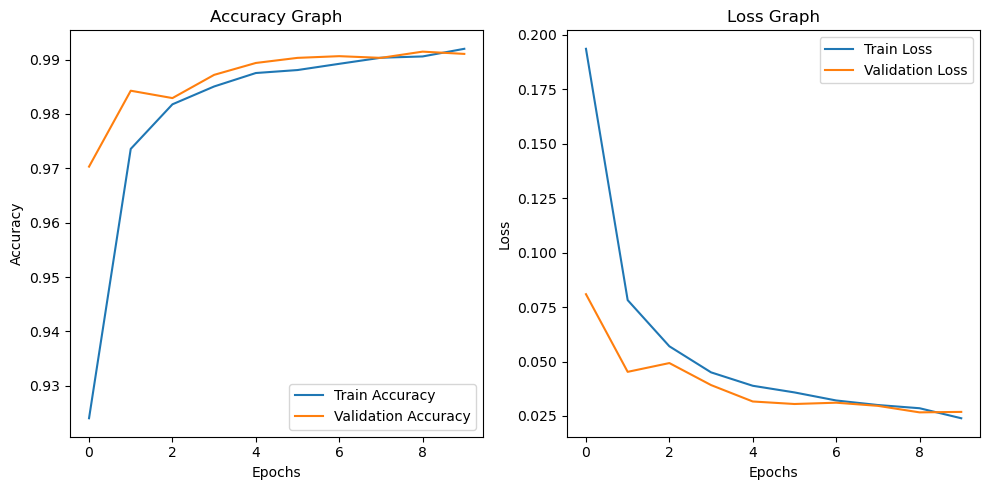

NameError: name 'X_test' is not defined

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# 1. GENERATE ACCURACY AND LOSS GRAPHS
def plot_history(history):
    # Accuracy Plot
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Graph')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Graph')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

# 2. GENERATE CONFUSION MATRIX AND CLASSIFICATION REPORT
def plot_results(model, X_test, y_test):
    # Predictions
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Alert', 'Drowsy'], 
                yticklabels=['Alert', 'Drowsy'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Detailed Text Report
    print("Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=['Alert', 'Drowsy']))

# 3. GENERATE ROC CURVE
def plot_roc(model, X_test, y_test):
    y_pred_probs = model.predict(X_test)[:, 1] # Probability for 'Drowsy' class
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='darkorange', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.show()

# --- EXECUTION ---
# Call these functions after model.fit()
plot_history(history)
plot_results(model, X_test, y_test)
plot_roc(model, X_test, y_test)